# Tugas 1 - Klasifikasi Jamur dengan Naive Bayes

| Nama | NRP |
|------|-----|
| Faiz Farrosian Karim | 5054251027|

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Mushroom Dataset dari UCI Machine Learning Repository.

Dataset dapat diakses melalui:
- https://www.kaggle.com/datasets/uciml/mushroom-classification

Untuk metadata / penjelasan mengenai dataset bisa mengakses link berikut:
- https://archive.ics.uci.edu/dataset/73/mushroom

Tujuan utama dari tugas ini adalah membangun dan membandingkan tiga varian Naive Bayes, yaitu Categorical NB, Bernoulli NB, dan Multinomial NB, untuk mengklasifikasikan apakah suatu jamur dapat dimakan (edible) atau beracun (poisonous).

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan untuk masing-masing varian Naive Bayes.
3. Eksperimen Model
   - Bangun model Categorical NB, Bernoulli NB, dan Multinomial NB.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil ketiga model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.naive_bayes import CategoricalNB, BernoulliNB, MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_curve, auc

sns.set_style('whitegrid')


In [2]:
# Load dataset dan tampilkan beberapa baris pertama.
# Semua nilai pada dataset berupa single character yang merupakan kode singkatan dari kategori.
# Contoh: pada kolom class, e = edible dan p = poisonous.
df = pd.read_csv('mushrooms.csv')
df.head()


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [3]:
# Tampilkan informasi dasar dataset: jumlah baris dan kolom, tipe data, dan jumlah missing value.
# Perhatikan kolom stalk-root yang memiliki nilai '?' sebagai representasi missing value.
print('Jumlah baris dan kolom:', df.shape)
df.info()

print()
print('Jumlah nilai "?" pada tiap kolom:')
print((df == '?').sum())


Jumlah baris dan kolom: (8124, 23)
<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8124 non-null   str  
 1   cap-shape                 8124 non-null   str  
 2   cap-surface               8124 non-null   str  
 3   cap-color                 8124 non-null   str  
 4   bruises                   8124 non-null   str  
 5   odor                      8124 non-null   str  
 6   gill-attachment           8124 non-null   str  
 7   gill-spacing              8124 non-null   str  
 8   gill-size                 8124 non-null   str  
 9   gill-color                8124 non-null   str  
 10  stalk-shape               8124 non-null   str  
 11  stalk-root                8124 non-null   str  
 12  stalk-surface-above-ring  8124 non-null   str  
 13  stalk-surface-below-ring  8124 non-null   str  
 14  stalk-color-abov

In [4]:
# Tampilkan jumlah nilai unik pada setiap fitur.
# Perhatikan variasi jumlah kategori antar fitur, misalnya veil-type hanya punya 1 nilai unik.
df.nunique()


class                        2
cap-shape                    6
cap-surface                  4
cap-color                   10
bruises                      2
odor                         9
gill-attachment              2
gill-spacing                 2
gill-size                    2
gill-color                  12
stalk-shape                  2
stalk-root                   5
stalk-surface-above-ring     4
stalk-surface-below-ring     4
stalk-color-above-ring       9
stalk-color-below-ring       9
veil-type                    1
veil-color                   4
ring-number                  3
ring-type                    5
spore-print-color            9
population                   6
habitat                      7
dtype: int64

class
e    4208
p    3916
Name: count, dtype: int64


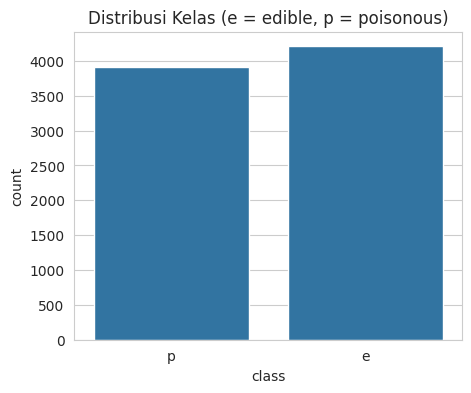

In [5]:
# Tampilkan distribusi kelas target (class) dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
print(df['class'].value_counts())

plt.figure(figsize=(5,4))
sns.countplot(x='class', data=df)
plt.title('Distribusi Kelas (e = edible, p = poisonous)')
plt.show()


In [6]:
# EDA tambahan: lihat hubungan fitur odor dengan class,
# karena odor kelihatannya fitur yang cukup kuat membedakan jamur beracun/tidak.
pd.crosstab(df['odor'], df['class'])


class,e,p
odor,,
a,400,0
c,0,192
f,0,2160
l,400,0
m,0,36
n,3408,120
p,0,256
s,0,576
y,0,576


## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

Karena semua fitur bertipe kategorikal, setiap varian Naive Bayes membutuhkan representasi data yang berbeda:

| Model | Representasi yang dibutuhkan | Preprocessing |
|---|---|---|
| Categorical NB | Integer per kategori | OrdinalEncoder |
| Bernoulli NB | Binary 0/1 per kategori | LabelBinarizer / OneHotEncoder |
| Multinomial NB | Count / frekuensi non-negatif | OneHotEncoder |

In [7]:
# Tangani missing value pada kolom stalk-root (nilai '?').
# Di sini nilai '?' dianggap sebagai kategori tersendiri (misalnya artinya "tidak diketahui"),
# jadi tidak perlu diubah/dihapus karena semua fitur memang berupa kategori.
print(df['stalk-root'].value_counts())


stalk-root
b    3776
?    2480
e    1120
c     556
r     192
Name: count, dtype: int64


In [8]:
# Periksa apakah ada fitur yang hanya memiliki satu nilai unik.
# Fitur seperti itu tidak memberikan informasi apapun dan sebaiknya di-drop.
kolom_konstan = [kol for kol in df.columns if df[kol].nunique() == 1]
print('Kolom dengan 1 nilai unik:', kolom_konstan)

df = df.drop(columns=kolom_konstan)
df.head()


Kolom dengan 1 nilai unik: ['veil-type']


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,s,w,w,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,s,w,w,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,s,w,w,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,s,w,w,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,s,w,w,w,o,e,n,a,g


In [9]:
# Pisahkan fitur (X) dan target (y).
# Encode target: e = 0 (edible), p = 1 (poisonous).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
X = df.drop(columns=['class'])
y = df['class'].map({'e': 0, 'p': 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)


X_train: (6499, 21)
X_test : (1625, 21)


In [10]:
# Preprocessing untuk Categorical NB:
# Gunakan OrdinalEncoder untuk mengubah setiap kategori menjadi integer.
# Contoh: cap-shape b=0, c=1, f=2, k=3, s=4, x=5
# Fit hanya pada train set, transform pada train set dan test set.
ord_enc = OrdinalEncoder()
X_train_ord = ord_enc.fit_transform(X_train)
X_test_ord = ord_enc.transform(X_test)

print(X_train_ord[:5])


[[ 2.  3.  9.  0.  2.  1.  0.  0.  2.  0.  1.  1.  1.  6.  0.  2.  1.  2.
   1.  5.  1.]
 [ 5.  2.  5.  1.  5.  1.  0.  0.  1.  0.  0.  2.  2.  2.  7.  2.  2.  0.
   7.  1.  6.]
 [ 0.  2.  3.  0.  5.  1.  1.  0. 10.  0.  0.  1.  2.  7.  7.  2.  2.  4.
   7.  3.  1.]
 [ 2.  2.  4.  0.  7.  1.  0.  1.  0.  1.  0.  1.  1.  6.  7.  2.  1.  0.
   7.  4.  0.]
 [ 3.  3.  4.  0.  2.  1.  0.  1.  0.  1.  0.  2.  1.  6.  6.  2.  1.  0.
   7.  4.  4.]]


In [11]:
# Preprocessing untuk Bernoulli NB dan Multinomial NB:
# Gunakan OneHotEncoder untuk mengubah setiap kategori menjadi representasi binary.
# Hasilnya berupa matriks sparse dengan nilai 0 dan 1.
# Fit hanya pada train set, transform pada train set dan test set.
ohe = OneHotEncoder(handle_unknown='ignore')
X_train_ohe = ohe.fit_transform(X_train)
X_test_ohe = ohe.transform(X_test)

print('Bentuk hasil one-hot encoding:', X_train_ohe.shape)


Bentuk hasil one-hot encoding: (6499, 116)


# 3. Eksperimen Model

## 3.1 Categorical Naive Bayes

CategoricalNB adalah varian yang paling sesuai untuk dataset ini karena semua fitur memang bertipe kategorikal. Model menghitung P(fitur=kategori | kelas) secara langsung untuk setiap kategori pada setiap fitur.

In [12]:
# Inisialisasi dan latih model CategoricalNB menggunakan train set hasil OrdinalEncoder.
model_cnb = CategoricalNB()
model_cnb.fit(X_train_ord, y_train)


,"alpha alpha: float, default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"min_categories min_categories: int or array-like of shape (n_features,), default=NoneMinimum number of categories per feature.- integer: Sets the minimum number of categories per feature to `n_categories` for each features.- array-like: shape (n_features,) where `n_categories[i]` holds the minimum number of categories for the ith column of the input.- None (default): Determines the number of categories automatically from the training data... versionadded:: 0.24",None


In [13]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_cnb = model_cnb.predict(X_test_ord)
y_proba_cnb = model_cnb.predict_proba(X_test_ord)[:, 1]


## 3.2 Bernoulli Naive Bayes

BernoulliNB bekerja pada representasi binary. Dengan OneHotEncoder, setiap kategori menjadi kolom tersendiri bernilai 0 atau 1, sehingga model memperlakukan setiap kategori sebagai fitur binary ada/tidak ada.

In [14]:
# Inisialisasi dan latih model BernoulliNB menggunakan train set hasil OneHotEncoder.
model_bnb = BernoulliNB()
model_bnb.fit(X_train_ohe, y_train)


,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"binarize binarize: float or None, default=0.0Threshold for binarizing (mapping to booleans) of sample features.If None, input is presumed to already consist of binary vectors.",0.0
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [15]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_bnb = model_bnb.predict(X_test_ohe)
y_proba_bnb = model_bnb.predict_proba(X_test_ohe)[:, 1]


## 3.3 Multinomial Naive Bayes

MultinomialNB membutuhkan input non-negatif dan menginterpretasikannya sebagai frekuensi. Dengan OneHotEncoder yang menghasilkan nilai 0 dan 1, model dapat menerimanya sebagai counts meskipun secara semantik tiap nilai hanya menandakan ada/tidak ada kategori.

In [16]:
# Inisialisasi dan latih model MultinomialNB menggunakan train set hasil OneHotEncoder.
model_mnb = MultinomialNB()
model_mnb.fit(X_train_ohe, y_train)


,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [17]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_mnb = model_mnb.predict(X_test_ohe)
y_proba_mnb = model_mnb.predict_proba(X_test_ohe)[:, 1]


# 4. Evaluasi Model

In [18]:
# Tampilkan metrik evaluasi untuk setiap model: Accuracy, Precision, Recall, dan F1-Score.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.
hasil = {
    'Model': ['Categorical NB', 'Bernoulli NB', 'Multinomial NB'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_cnb),
        accuracy_score(y_test, y_pred_bnb),
        accuracy_score(y_test, y_pred_mnb),
    ],
    'Precision': [
        precision_score(y_test, y_pred_cnb),
        precision_score(y_test, y_pred_bnb),
        precision_score(y_test, y_pred_mnb),
    ],
    'Recall': [
        recall_score(y_test, y_pred_cnb),
        recall_score(y_test, y_pred_bnb),
        recall_score(y_test, y_pred_mnb),
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_cnb),
        f1_score(y_test, y_pred_bnb),
        f1_score(y_test, y_pred_mnb),
    ],
}

df_hasil = pd.DataFrame(hasil)
df_hasil


,Model,Accuracy,Precision,Recall,F1-Score
0,Categorical NB,0.945846,0.990127,0.896552,0.941019
1,Bernoulli NB,0.932923,0.981429,0.877395,0.926500
2,Multinomial NB,0.945846,0.990127,0.896552,0.941019


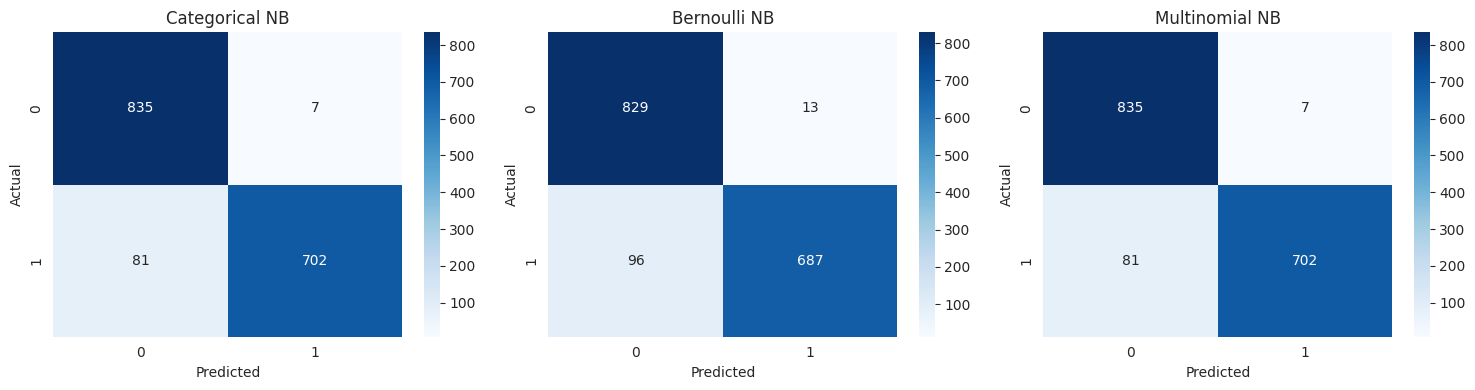

In [19]:
# Tampilkan Confusion Matrix setiap model dalam bentuk heatmap.
# Susun ketiganya dalam satu baris subplot.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

preds = [y_pred_cnb, y_pred_bnb, y_pred_mnb]
judul = ['Categorical NB', 'Bernoulli NB', 'Multinomial NB']

for ax, pred, title in zip(axes, preds, judul):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()


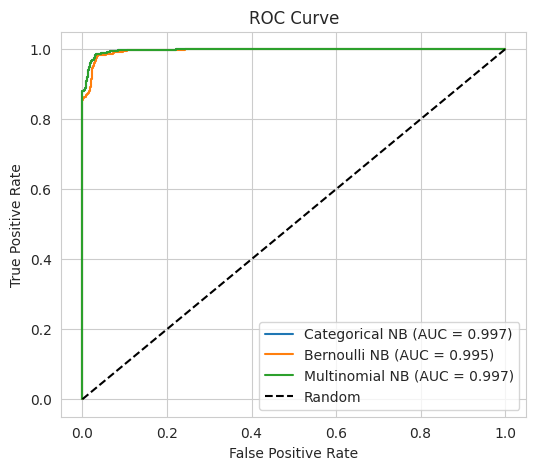

In [20]:
# Tampilkan ROC Curve ketiga model dalam satu plot beserta nilai AUC masing-masing.
probas = [y_proba_cnb, y_proba_bnb, y_proba_mnb]

plt.figure(figsize=(6, 5))
for proba, title in zip(probas, judul):
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{title} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


# 5. Analisis

#### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan. Bandingkan performa Categorical NB, Bernoulli NB, dan Multinomial NB berdasarkan hasil evaluasi. Kaitkan perbedaan performa dengan perbedaan representasi data yang digunakan oleh masing-masing model. Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan.

Dari hasil eksperimen di atas, ketiga model sama-sama menghasilkan performa yang tinggi pada dataset mushroom ini, dengan akurasi di atas 93%. Berikut perbandingannya:

- **Categorical NB** dan **Multinomial NB** memberikan hasil yang identik, yaitu Accuracy 0.946, Precision 0.990, Recall 0.897, dan F1-Score 0.941, dengan AUC sebesar 0.997.
- **Bernoulli NB** sedikit lebih rendah, dengan Accuracy 0.933, Precision 0.981, Recall 0.877, F1-Score 0.927, dan AUC 0.995.

Precision pada ketiga model jauh lebih tinggi dibanding Recall. Artinya, ketika model memprediksi jamur sebagai *poisonous*, prediksi itu hampir selalu benar, tetapi masih ada sebagian jamur beracun yang justru diprediksi sebagai *edible* (false negative). Hal ini terlihat juga pada confusion matrix, di mana jumlah false negative lebih banyak dibanding false positive pada ketiga model.

Perbedaan performa ini berkaitan dengan representasi data yang dipakai tiap model:
- Categorical NB memakai OrdinalEncoder, sehingga tiap fitur direpresentasikan sebagai satu kolom kategori integer. Representasi ini paling sesuai dengan asumsi CategoricalNB, karena model memang dirancang untuk menghitung probabilitas tiap kategori pada tiap fitur secara langsung.
- Bernoulli NB memakai OneHotEncoder, di mana tiap kategori menjadi kolom biner tersendiri. BernoulliNB memperlakukan tiap kolom sebagai "ada/tidak ada" fitur, sehingga model juga memperhitungkan probabilitas ketidakhadiran suatu kategori. Hal ini membuat asumsinya sedikit berbeda dari struktur data aslinya, sehingga performanya sedikit lebih rendah dibanding dua model lainnya.
- Multinomial NB juga memakai OneHotEncoder yang sama dengan Bernoulli NB, tetapi karena tiap fitur mushroom hanya bernilai 0/1 (bukan count sebenarnya), MultinomialNB pada kasus ini berperilaku mirip seperti menghitung "frekuensi" munculnya tiap kategori, yang kebetulan hasilnya setara dengan Categorical NB pada dataset ini.

Secara keseluruhan, ketiga model NB bekerja dengan sangat baik pada dataset ini karena seluruh fitur memang bertipe kategorikal dan cukup informatif (misalnya fitur odor yang terlihat jelas membedakan kelas edible dan poisonous pada tahap EDA).

# 6. Kesimpulan dan Saran

#### Berikan kesimpulan dari eksperimen yang telah dilakukan. Saran dapat berupa rekomendasi untuk eksperimen selanjutnya, perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

**Kesimpulan:**
1. Ketiga varian Naive Bayes (Categorical, Bernoulli, dan Multinomial) mampu mengklasifikasikan jamur edible/poisonous dengan performa yang tinggi (akurasi 93-95%, AUC di atas 0.99).
2. Categorical NB dan Multinomial NB memberikan hasil terbaik dan identik pada eksperimen ini, sedangkan Bernoulli NB sedikit lebih rendah karena representasi biner yang dipakainya kurang sesuai dengan struktur data kategorikal aslinya.
3. Precision model jauh lebih tinggi dibanding Recall, sehingga model lebih sering "ragu" (memprediksi edible padahal sebenarnya poisonous) dibanding sebaliknya. Untuk kasus keamanan pangan seperti ini, kesalahan recall (false negative) jauh lebih berbahaya dibanding false positive.

**Saran untuk eksperimen selanjutnya:**
- Mencoba strategi penanganan missing value yang berbeda pada kolom stalk-root (misalnya diisi dengan modus) untuk melihat apakah hasil model berubah.
- Melakukan feature selection untuk melihat fitur mana saja yang paling berpengaruh terhadap prediksi (misalnya lewat feature importance atau analisis odor yang terlihat sangat dominan pada tahap EDA).
- Membandingkan hasil ketiga model Naive Bayes ini dengan model lain seperti Logistic Regression atau Decision Tree sebagai pembanding performa.